# SLEAP Model Analysis
Analysis of centroid + centered instance model predictions for card corner tracking.

**Models used:**
- Centroid: `260415_100132.centroid.n=21`
- Centered instance: `260415_100638.centered_instance.n=21`

In [7]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("/Users/zosiasus/Documents/Aeon3_SLEAP/AEON_sleap_analysis")
SCRIPTS_DIR = PROJECT_ROOT / "scripts"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

In [8]:
from plot_sleap_model_performance import (
    summarize,
    plot_scoreboard,
    plot_training_curves,
    plot_distance_distribution,
    plot_pck_curves,
    plot_part_accuracy,
    write_summary,
)

In [ ]:
CENTROID_MODEL = Path(
    "/Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/card_recognitions_sleap/models/260415_100132.centroid.n=21"
)

INSTANCE_MODEL = Path(
    "/Users/zosiasus/Documents/Aeon3_SLEAP/aeon3_data/card_recognitions_sleap/models/260415_100638.centered_instance.n=21"
)

PART_NAMES = ["corner_1", "corner_2", "corner_3", "corner_4"]

MODELS = {
    "centroid": CENTROID_MODEL,
    "instance": INSTANCE_MODEL,
}

In [10]:
for model in models:
    print(model["name"])
    print("  val mOKS:", model["val"]["mOKS"]["mOKS"])
    print("  val mPCK:", model["val"]["pck_metrics"]["mPCK"])
    print("  val PCK@5:", model["val"]["pck_metrics"]["PCK@5"])
    print("  val avg pixel error:", model["val"]["distance_metrics"]["avg"])
    print()


260415_100132.centroid.n=21
  val mOKS: 0.9999999998788546
  val mPCK: 1.0
  val PCK@5: 1.0
  val avg pixel error: 2.4736100876555188e-05

260415_100638.centered_instance.n=21
  val mOKS: 0.1859560245899941
  val mPCK: 0.32499999999999996
  val PCK@5: 0.25
  val avg pixel error: 6.087864923279952



In [11]:
scoreboard_path = plot_scoreboard(models, OUTDIR)
training_path = plot_training_curves(models, OUTDIR)
distance_path = plot_distance_distribution(models, OUTDIR)
pck_path = plot_pck_curves(models, OUTDIR)
part_path = plot_part_accuracy(models, OUTDIR)

report_path = write_summary(
    models,
    OUTDIR,
    [scoreboard_path, training_path, distance_path, pck_path, part_path],
)

print(report_path)


/Users/zosiasus/Documents/Aeon3_SLEAP/AEON_sleap_analysis/outputs/top_camera_model_analysis/first_model_performance_report.md


scoreboard.png


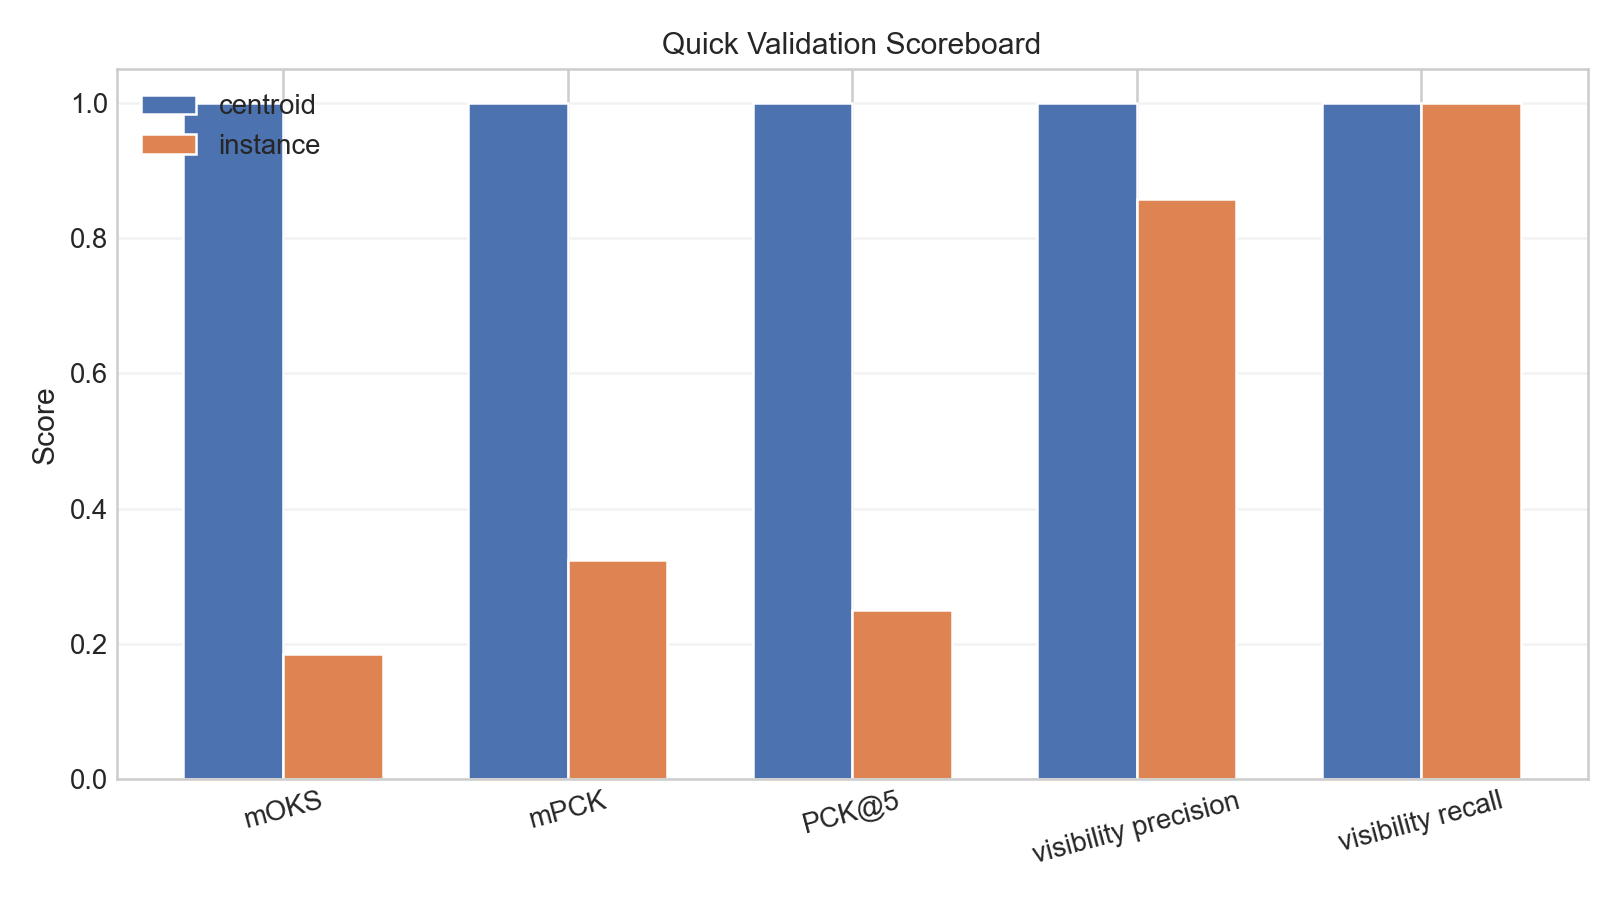

training_curves.png


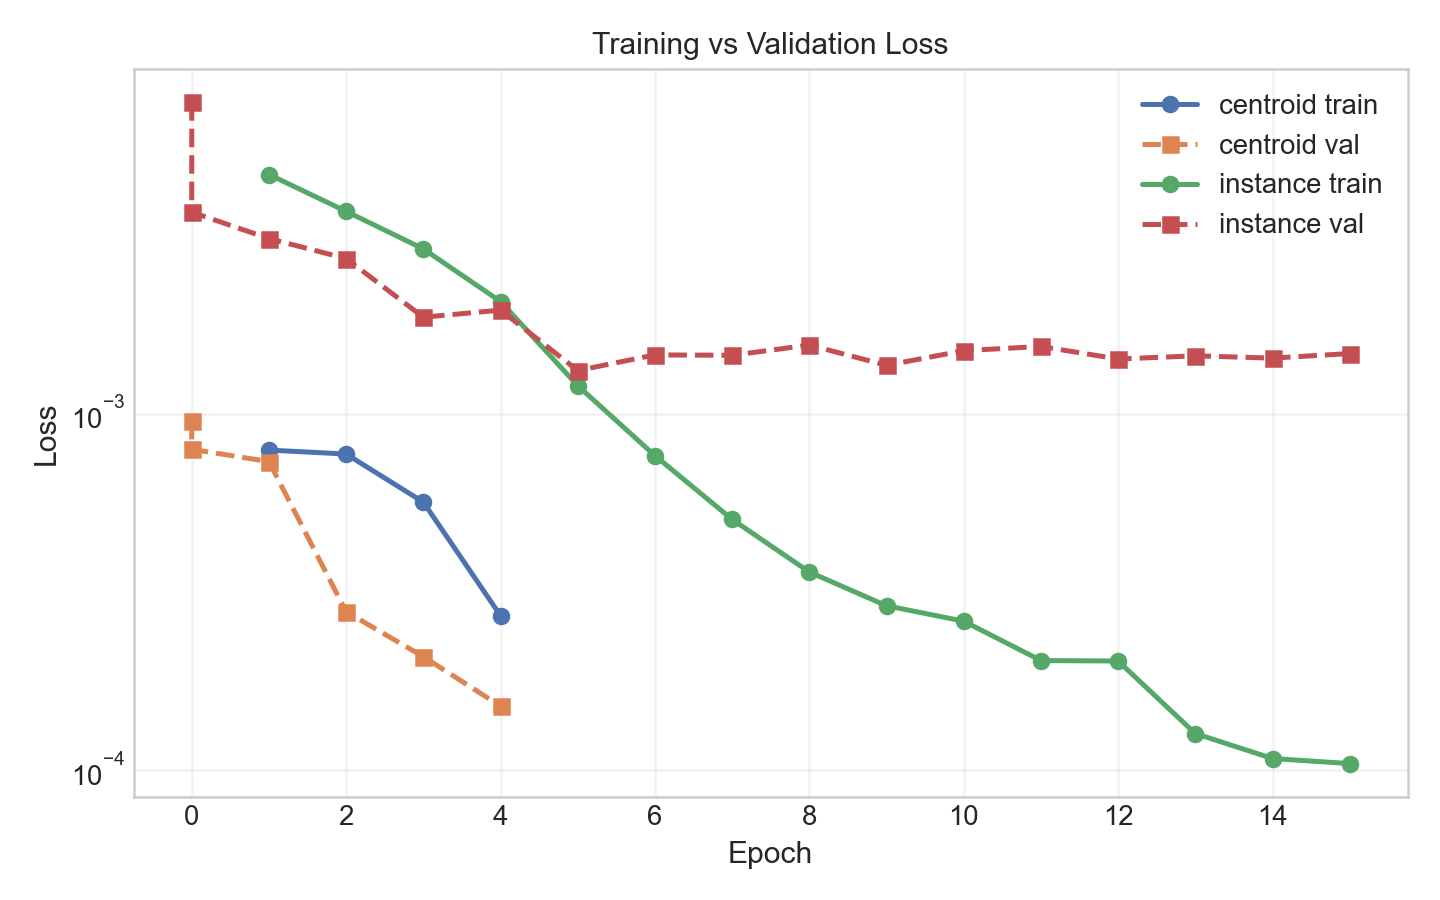

distance_distribution.png


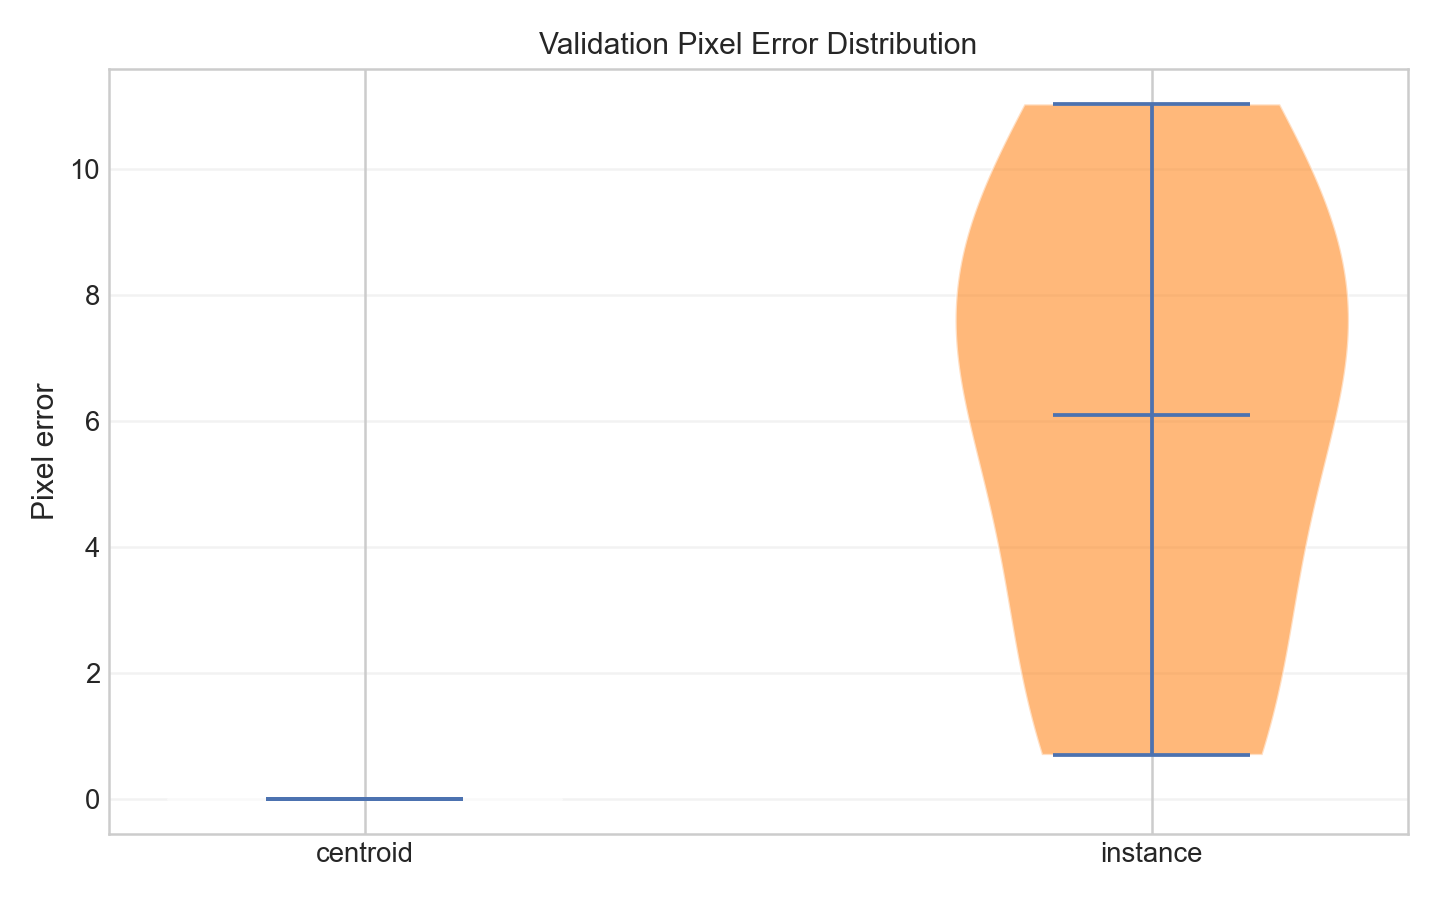

pck_curves.png


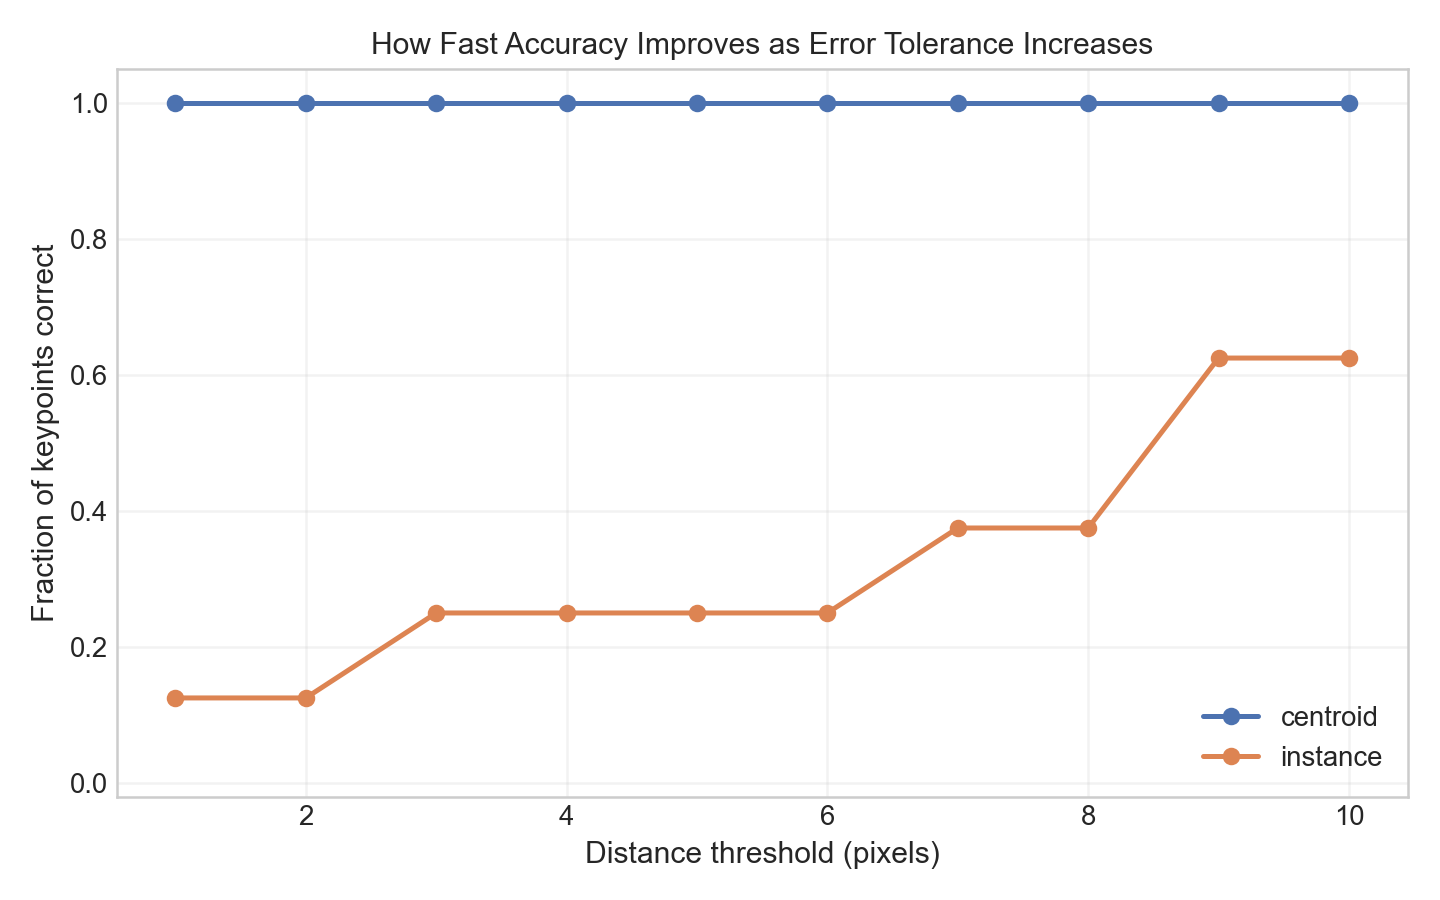

part_accuracy.png


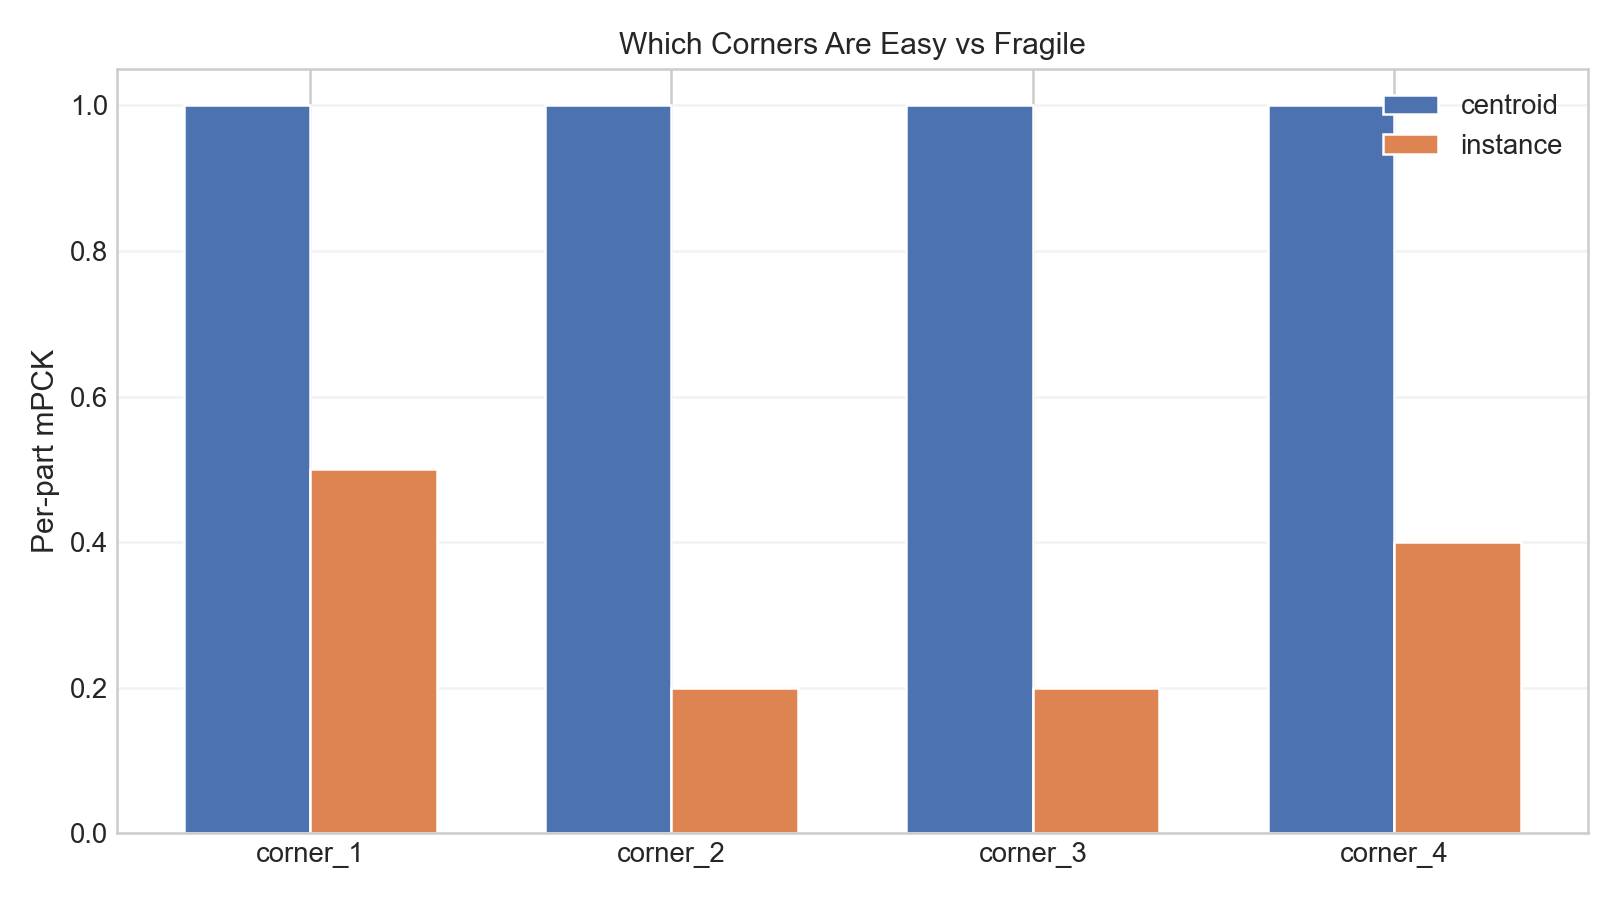

In [12]:
from IPython.display import Image, display

for path in [scoreboard_path, training_path, distance_path, pck_path, part_path]:
    print(path.name)
    display(Image(filename=str(path)))


## What the metrics mean

### `mOKS`
`mOKS` means mean Object Keypoint Similarity.

It tells you how close the predicted keypoints are to the true labeled keypoints, while scaling for object size.  
Higher is better.

- `1.0` means the predictions match the labels extremely well.
- Closer to `0` means the predicted points are far from the true points.

For this card-tracking project, a high `mOKS` means the model is placing the card corners in the right places overall.

---

### `mPCK`
`mPCK` means mean Percentage of Correct Keypoints.

It measures the fraction of keypoints that are counted as correct, based on whether they fall within a distance threshold from the true labeled point.  
Higher is better.

- `1.0` means all keypoints are being placed correctly.
- `0.5` means only about half are close enough.

For this project, a high `mPCK` means the model is consistently finding the corners close enough to the correct positions.

---

### `PCK@5`
`PCK@5` means Percentage of Correct Keypoints at a 5-pixel threshold.

This asks: what fraction of predicted points landed within 5 pixels of the true labeled point?  
Higher is better.

- `1.0` means every point is within 5 pixels.
- Lower values mean more predictions are missing by more than 5 pixels.

For this project, `PCK@5` is a practical measure of how precisely the model places the card corners.

---

### `Visibility precision`
This tells you how often the model was correct when it predicted that a keypoint was visible.  
Higher is better.

In other words:
- Of all the points the model said were visible, how many really were visible?

Low precision means the model is predicting points that should not be there.

For this project, low visibility precision can mean the model hallucinates card corners when they are occluded or unclear.

---

### `Visibility recall`
This tells you how often the model successfully detected keypoints that really were visible.  
Higher is better.

In other words:
- Of all the points that truly were visible, how many did the model find?

Low recall means the model is missing real points.

For this project, low visibility recall means the model fails to recover corners that should have been detected.

---

### `Training loss`
Training loss is the error on the training data during learning.  
Lower is better.

It tells you how well the model is fitting the examples it saw during training.

If training loss decreases, the model is learning the training set.  
But training loss alone is not enough, because a model can memorize the training data without generalizing well.

---

### `Validation loss`
Validation loss is the error on held-out validation data.  
Lower is better.

This is usually more important than training loss because it tells you how well the model generalizes to unseen labeled frames.

A useful guide:
- Training loss down and validation loss down: good.
- Training loss down but validation loss flat or rising: overfitting.
- Both high: the model is not learning well.

---

### `Pixel error`
Pixel error is the distance in pixels between the predicted point and the true labeled point.  
Lower is better.

For example:
- `1 px` means the prediction is very close.
- `10 px` means the prediction is noticeably off.

For this project, this is one of the most intuitive metrics because it tells you how far each predicted corner is from where it should be.

---

### `PCK curve`
The PCK curve shows how accuracy changes as you allow a larger error tolerance.

- The x-axis is the allowed distance threshold in pixels.
- The y-axis is the fraction of keypoints counted as correct.

Interpretation:
- A strong model rises quickly and stays high.
- A weak model only looks good when the threshold becomes large.

For this project, if a model only becomes good at large thresholds, it means the corner placement is sloppy.

---

### `Per-part mPCK`
This shows `mPCK` separately for each keypoint, such as `corner_1`, `corner_2`, `corner_3`, and `corner_4`.

It helps show whether:
- one corner is consistently harder than the others
- failures are concentrated in specific parts rather than across the whole card

For this project, this is useful if some corners are more often occluded, blurrier, or harder to label consistently.

---

## What each plot is showing

### Scoreboard plot
This is the quick overall summary.

It compares models across:
- `mOKS`
- `mPCK`
- `PCK@5`
- visibility precision
- visibility recall

Use it to quickly see which model is stronger overall.

---

### Training curves plot
This shows:
- training loss over epochs
- validation loss over epochs

Use it to see:
- whether the model learned smoothly
- whether it overfit
- whether training stopped too early or too late

---

### Distance distribution plot
This shows the spread of pixel errors.

Use it to see:
- whether predictions are tightly clustered near the true labels
- whether the model sometimes makes very large mistakes

A wider distribution usually means a weaker or less stable model.

---

### PCK curves plot
This shows how the model behaves under stricter versus more forgiving distance thresholds.

Use it to see:
- whether a model is already accurate at small thresholds
- whether it only looks good when the threshold becomes generous

---

### Part accuracy plot
This shows which keypoints are easiest and hardest for the model.

Use it to see:
- whether failures are concentrated on specific corners
- whether labeling issues, viewpoint, blur, or occlusion affect certain parts more than others

---

## Interpretation for this best-performing model pair

For the current best-performing pair:
- The `centroid` model is the detector: it finds where the card is.
- The `centered_instance` model is the localizer: it refines the card corners after the centroid is found.

So when other models fail, these plots help answer:
- Did the detector fail to find the card at all?
- Or did the instance model find the card but place the corners badly?

One important caution: the saved validation metrics here were computed on only a very small validation set, so these plots are excellent for diagnosis, but not the final proof of model quality.
